# 6CS012 : Final Portfolio Assessment 2026
## Part III: Sarcasm Detection using RNN, LSTM and GloVe Embeddings


#### **Student ID**: 2408863
#### **Full Name** : Prabesh Raj Maharjan
#### **Dataset**: Sarcastic or Not Sarcastic Headlines
#### **Total Samples**: 28,619 headlines
#### **Class Balance** : 52.4% not sarcastic & 47.6% sarcastic



### Dataset Summary
- **28,619** news headlines labelled as sarcastic (1) or not sarcastic (0)
- **Average headline length**: ~10 words
- **Text column**: `headline` , **Label column**: `is_sarcastic`

## Step 0 :Install Dependencies

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install -q gradio wordcloud nltk gensim contractions pyahocorasick

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('All dependencies ready.')
print('Upload sarcastic_headlines.csv via Files panel')

print('All dependencies ready.')
print('All dependencies ready.')
print('Upload sarcastic_headlines.csv via the Files panel (left sidebar)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 35.4 MB/s eta 0:00:00
All dependencies ready.
Upload sarcastic_headlines.csv via Files panel
All dependencies ready.
All dependencies ready.
Upload sarcastic_headlines.csv via the Files panel (left sidebar)


## Step 1: Imports & Global Configuration

In [3]:
import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
warnings.filterwarnings('ignore')

import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import gensim.downloader as gensim_api

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Global Config
DATASET_PATH  = '/content/drive/MyDrive/Ai and Machine Learning/sarcastic_headlines.csv'
MAX_WORDS     = 10000
EMBEDDING_DIM = 50           # GloVe Twitter 50d
BATCH_SIZE    = 64
EPOCHS        = 20
CLASS_NAMES   = ['not sarcastic', 'sarcastic']
NUM_CLASSES   = 2

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print(f'TensorFlow   : {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow   : 2.20.0
GPU available: True


## Step 2 : Load Dataset & Explore

In [4]:
df = pd.read_csv(DATASET_PATH)

print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
print(f'Nulls   : {df.isnull().sum().to_dict()}')
print(f'\nClass distribution:')
print(df['is_sarcastic'].value_counts())
print(f'\nBalance: {df["is_sarcastic"].value_counts(normalize=True).round(3).to_dict()}')
print(f'\nSample headlines:')
df[['headline','is_sarcastic']].head(6)

Shape   : (28619, 2)
Columns : ['headline', 'is_sarcastic']
Nulls   : {'headline': 0, 'is_sarcastic': 0}

Class distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Balance: {0: 0.524, 1: 0.476}

Sample headlines:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1
5,my white inheritance,0


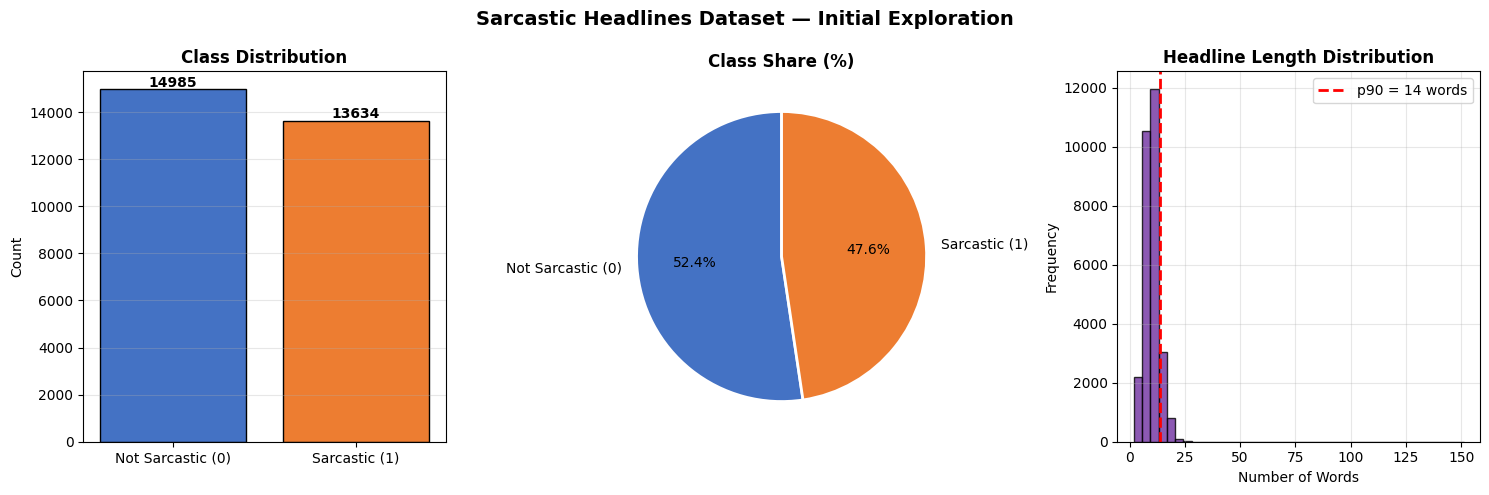

Mean headline length : 10.0 words
Max  headline length : 151 words
90th percentile      : 14 words


In [5]:
# Class distribution chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
dist   = df['is_sarcastic'].value_counts()
colors = ['#4472C4', '#ED7D31']
labels = ['Not Sarcastic (0)', 'Sarcastic (1)']

# Bar chart
bars = axes[0].bar(labels, dist.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 str(val), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(dist.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Share (%)', fontweight='bold')

# Headline length distribution
lens = df['headline'].str.split().apply(len)
axes[2].hist(lens, bins=40, color='#7030A0', edgecolor='black', alpha=0.8)
axes[2].axvline(lens.quantile(0.90), color='red', linestyle='--', linewidth=2,
                label=f'p90 = {int(lens.quantile(0.90))} words')
axes[2].set_title('Headline Length Distribution', fontweight='bold')
axes[2].set_xlabel('Number of Words')
axes[2].set_ylabel('Frequency')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Sarcastic Headlines Dataset — Initial Exploration',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean headline length : {lens.mean():.1f} words')
print(f'Max  headline length : {lens.max()} words')
print(f'90th percentile      : {int(lens.quantile(0.90))} words')

## Step 3 : Text Preprocessing & Cleaning

In [6]:
# Text Cleaning Pipeline
def clean_text(text):
    text = str(text).lower()                          # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)        # 2. Remove URLs
    text = re.sub(r'@\w+', '', text)                  # 3. Remove @mentions
    text = re.sub(r'#\w+', '', text)                  # 4. Remove hashtags
    text = contractions.fix(text)                     # 5. Expand contractions
    text = re.sub(r'\d+', '', text)                   # 6. Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)              # 7. Remove special chars
    text = re.sub(r'\s+', ' ', text).strip()          # 8. Remove extra whitespace
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 1]  # 9. Stopwords + lemmatize
    return ' '.join(tokens)

print('Cleaning headlines...')
df['cleaned'] = df['headline'].apply(clean_text)

# Remove empty rows
df = df[df['cleaned'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

print(f'Dataset size after cleaning: {len(df)}')
print('\nBefore vs After Cleaning (5 examples):')
print('-'*75)
for i in range(5):
    lbl = 'SARCASTIC' if df['is_sarcastic'].iloc[i]==1 else 'NOT SARCASTIC'
    print(f'[{lbl}]')
    print(f'  ORIGINAL : {df["headline"].iloc[i]}')
    print(f'  CLEANED  : {df["cleaned"].iloc[i]}')
    print('-'*75)

Cleaning headlines...
Dataset size after cleaning: 28617

Before vs After Cleaning (5 examples):
---------------------------------------------------------------------------
[SARCASTIC]
  ORIGINAL : thirtysomething scientists unveil doomsday clock of hair loss
  CLEANED  : thirtysomething scientist unveil doomsday clock hair loss
---------------------------------------------------------------------------
[NOT SARCASTIC]
  ORIGINAL : dem rep. totally nails why congress is falling short on gender, racial equality
  CLEANED  : dem rep totally nail congress falling short gender racial equality
---------------------------------------------------------------------------
[NOT SARCASTIC]
  ORIGINAL : eat your veggies: 9 deliciously different recipes
  CLEANED  : eat veggie deliciously different recipe
---------------------------------------------------------------------------
[SARCASTIC]
  ORIGINAL : inclement weather prevents liar from getting to work
  CLEANED  : inclement weather prevents li

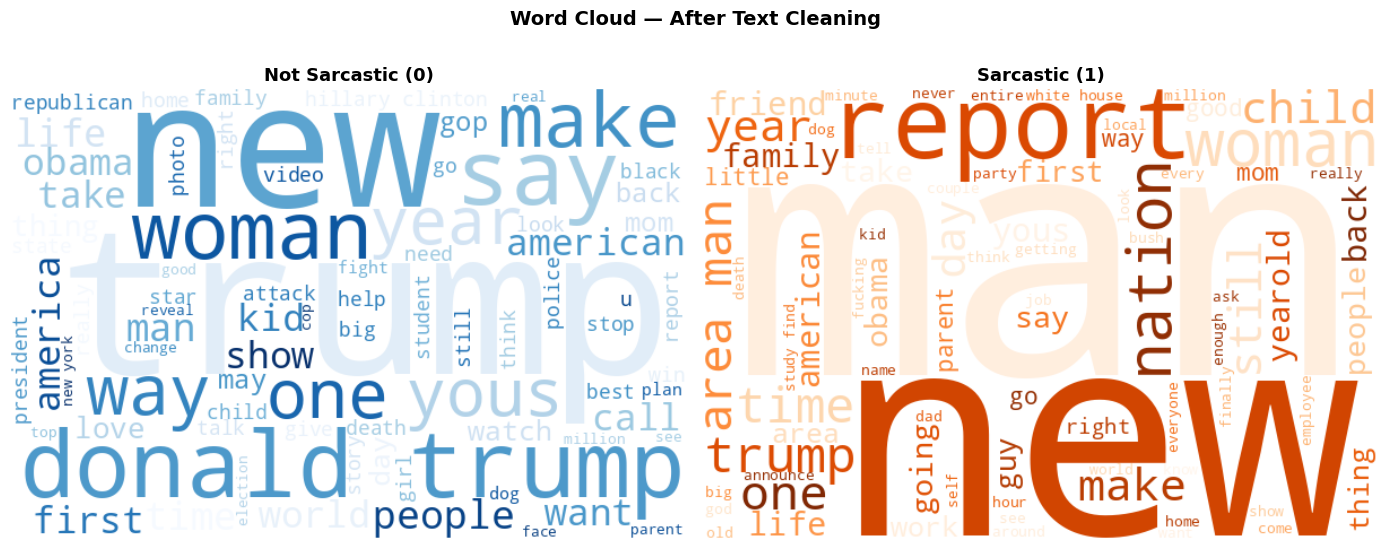

In [7]:
# Word Cloud per class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls_val, cls_name, cmap in zip(
    axes, [0, 1],
    ['Not Sarcastic (0)', 'Sarcastic (1)'],
    ['Blues', 'Oranges']
):
    text_blob = ' '.join(df[df['is_sarcastic']==cls_val]['cleaned'].values)
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=80).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cls_name, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Cloud — After Text Cleaning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

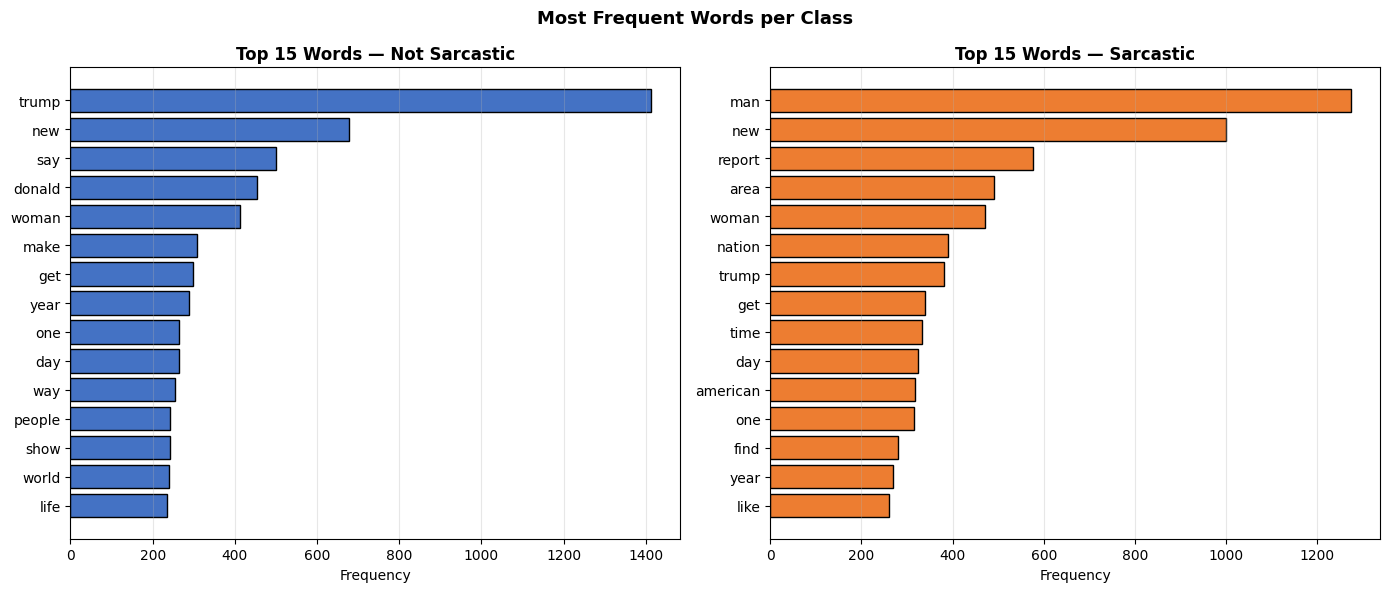

In [8]:
# Top 15 most frequent words per class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls_val, cls_name, color in zip(
    axes, [0, 1],
    ['Not Sarcastic', 'Sarcastic'],
    ['#4472C4', '#ED7D31']
):
    words = ' '.join(df[df['is_sarcastic']==cls_val]['cleaned'].values).split()
    top15 = Counter(words).most_common(15)
    w, c  = zip(*top15)
    ax.barh(w[::-1], c[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 15 Words — {cls_name}', fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Most Frequent Words per Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 : Tokenization, Padding & Train/Test Split

Train : 22893 | Test : 5724
Train dist: {np.int64(0): np.int64(11986), np.int64(1): np.int64(10907)}
Test  dist: {np.int64(0): np.int64(2997), np.int64(1): np.int64(2727)}

Vocabulary size : 10000
MAX_LEN (p90)   : 11 tokens


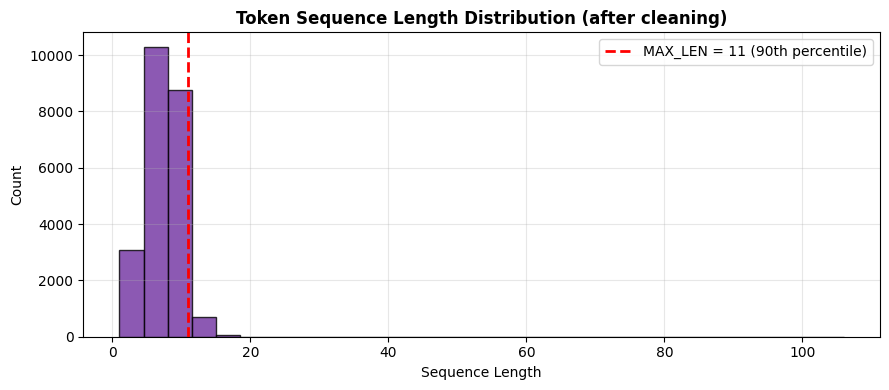

In [9]:
X = df['cleaned'].values
y = df['is_sarcastic'].values

#  80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train : {len(X_train)} | Test : {len(X_test)}')
print(f'Train dist: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test  dist: {dict(zip(*np.unique(y_test,  return_counts=True)))}')

# Tokenization (fit on train only)
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print(f'\nVocabulary size : {vocab_size}')

# Percentile-based padding (90th percentile)
seq_lens = [len(s) for s in X_train_seq]
# MAX_LEN  = int(np.percentile(seq_lens, 90))
MAX_LEN  = int(np.percentile(seq_lens, 95))
print(f'MAX_LEN (p90)   : {MAX_LEN} tokens')

# Sequence length distribution
plt.figure(figsize=(9, 4))
plt.hist(seq_lens, bins=30, color='#7030A0', edgecolor='black', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linewidth=2, linestyle='--',
            label=f'MAX_LEN = {MAX_LEN} (90th percentile)')
plt.title('Token Sequence Length Distribution (after cleaning)',
          fontweight='bold')
plt.xlabel('Sequence Length'); plt.ylabel('Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('seq_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
#Apply padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                             padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN,
                             padding='post', truncating='post')

print(f'X_train_pad shape : {X_train_pad.shape}')
print(f'X_test_pad  shape : {X_test_pad.shape}')
print('\nDataset is nearly balanced (52.4% vs 47.6%) — no class weighting needed.')

X_train_pad shape : (22893, 11)
X_test_pad  shape : (5724, 11)

Dataset is nearly balanced (52.4% vs 47.6%) — no class weighting needed.


## Step 5 : Helper Functions

In [11]:
def plot_history(history, title='Training History', save_name=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['loss'],         label='Train Loss', lw=2)
    ax1.plot(history.history['val_loss'],     label='Val Loss',   lw=2, ls='--')
    ax1.set_title('Loss Curves'); ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Train Acc',  lw=2)
    ax2.plot(history.history['val_accuracy'], label='Val Acc',    lw=2, ls='--')
    ax2.set_title('Accuracy Curves'); ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_name: plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

    tr = history.history['accuracy'][-1]
    vl = history.history['val_accuracy'][-1]
    gap = tr - vl
    print(f'\nBias-Variance: Train={tr:.4f} | Val={vl:.4f} | Gap={gap:.4f}')
    if gap > 0.08:   print('  >> HIGH VARIANCE — overfitting')
    elif tr < 0.70:  print('  >> HIGH BIAS — underfitting')
    else:            print('  >> GOOD FIT')


def evaluate_model(model, X_test, y_test, model_name='Model'):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'\n{model_name}')
    print(f'  Test Loss     : {loss:.4f}')
    print(f'  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ","_")}_cm.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    return loss, acc, y_pred

print('Helper functions ready.')

Helper functions ready.


## Step 6 : Model 1: Simple RNN + Trainable Embedding

In [12]:
# Model 1: Simple RNN
# rnn_model = models.Sequential(name='Simple_RNN', layers=[
#     layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
#                      input_length=MAX_LEN),
#     layers.SimpleRNN(64, return_sequences=False),
#     layers.Dropout(0.4),
#     layers.Dense(32, activation='relu'),
#     layers.Dropout(0.3),
#     layers.Dense(1, activation='sigmoid')   # binary → sigmoid
# ])
rnn_model = models.Sequential(name='Simple_RNN', layers=[
    layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
                     input_length=MAX_LEN),
    layers.SpatialDropout1D(0.3),
    layers.SimpleRNN(64, return_sequences=False),
    layers.Dropout(0.4),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks_base = [
    EarlyStopping(monitor='val_loss', patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1)
]

print('Training Model 1 — Simple RNN...')
t0 = time.time()
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=callbacks_base, verbose=1
)
rnn_time = time.time() - t0
print(f'RNN training time: {rnn_time:.1f}s ({rnn_time/60:.1f} min)')

Training Model 1 — Simple RNN...
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7177 - loss: 0.5458 - val_accuracy: 0.8008 - val_loss: 0.4366 - learning_rate: 0.0010
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8685 - loss: 0.3251 - val_accuracy: 0.7985 - val_loss: 0.4715 - learning_rate: 0.0010
Epoch 3/20
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9113 - loss: 0.2269
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9243 - loss: 0.2018 - val_accuracy: 0.7909 - val_loss: 0.5855 - learning_rate: 0.0010
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9616 - loss: 0.1101 - val_accuracy: 0.7979 - val_loss: 0.6777 - learning_rate: 5.0000e-04
Epoch 5/20
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9707 - loss: 0.0877
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

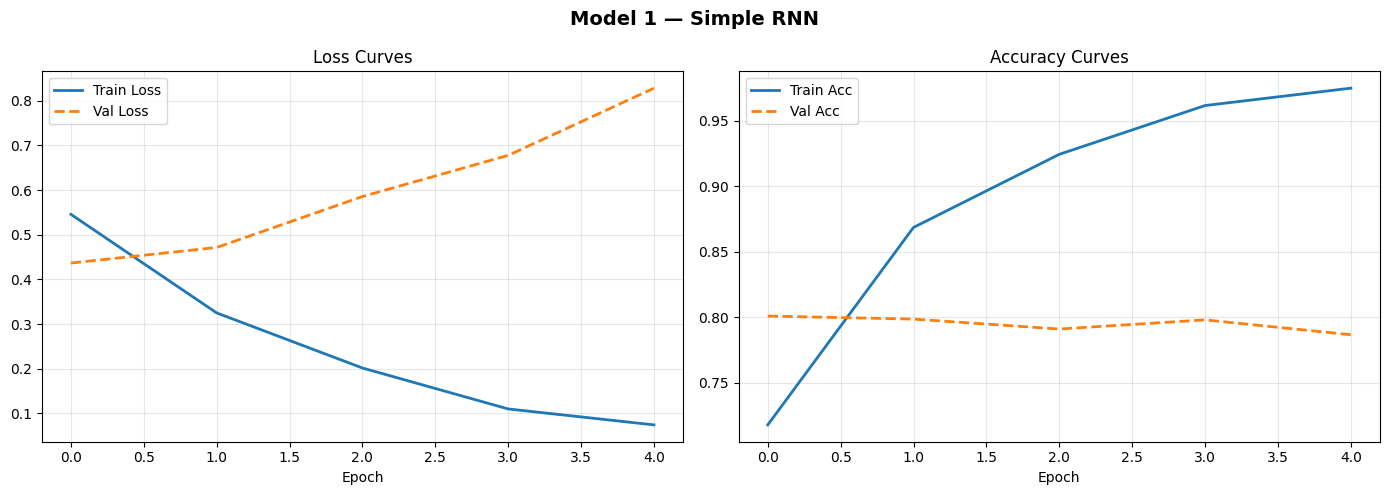


Bias-Variance: Train=0.9748 | Val=0.7865 | Gap=0.1883
  >> HIGH VARIANCE — overfitting

Model 1 Simple RNN
  Test Loss     : 0.4470
  Test Accuracy : 0.7867 (78.67%)

Classification Report:
               precision    recall  f1-score   support

not sarcastic       0.79      0.80      0.80      2997
    sarcastic       0.78      0.77      0.77      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



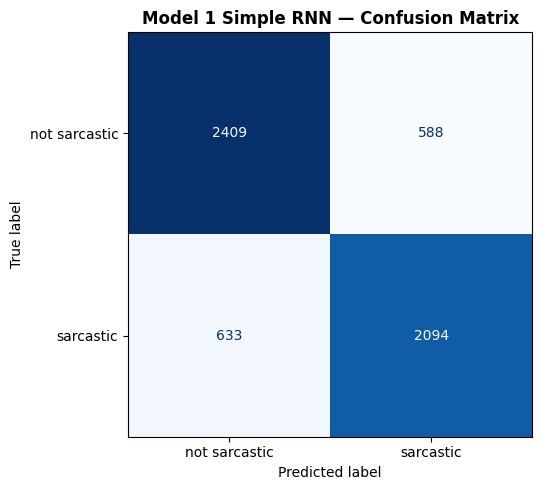

In [14]:
plot_history(history_rnn, 'Model 1 — Simple RNN', 'rnn_history.png')
rnn_loss, rnn_acc, rnn_preds = evaluate_model(
    rnn_model, X_test_pad, y_test, 'Model 1 Simple RNN'
)

## Step 7: Model 2: LSTM + Trainable Embedding

In [15]:
#  Model 2: Bidirectional LSTM
# lstm_model = models.Sequential(name='LSTM_Trainable', layers=[
#     layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
#                      input_length=MAX_LEN),
#     layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
#     layers.Dropout(0.4),
#     layers.LSTM(32),
#     layers.Dropout(0.3),
#     layers.Dense(64, activation='relu'),
#     layers.Dropout(0.3),
#     layers.Dense(1, activation='sigmoid')
# ])
lstm_model = models.Sequential(name='LSTM_Trainable', layers=[
    layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
                     input_length=MAX_LEN),
    layers.SpatialDropout1D(0.3),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Dropout(0.4),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
print('Training Model 2 — Bidirectional LSTM...')
t0 = time.time()
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=callbacks_base, verbose=1
)
lstm_time = time.time() - t0
print(f'LSTM training time: {lstm_time:.1f}s ({lstm_time/60:.1f} min)')

Training Model 2 — Bidirectional LSTM...
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7316 - loss: 0.5285 - val_accuracy: 0.7921 - val_loss: 0.4405 - learning_rate: 0.0010
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8423 - loss: 0.3600
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8568 - loss: 0.3378 - val_accuracy: 0.7979 - val_loss: 0.4602 - learning_rate: 0.0010
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9102 - loss: 0.2315 - val_accuracy: 0.8017 - val_loss: 0.5115 - learning_rate: 5.0000e-04
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9239 - loss: 0.2036
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9321 - loss: 0.1870 - val_accuracy: 0.7906 - val_loss: 0.5688 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring 

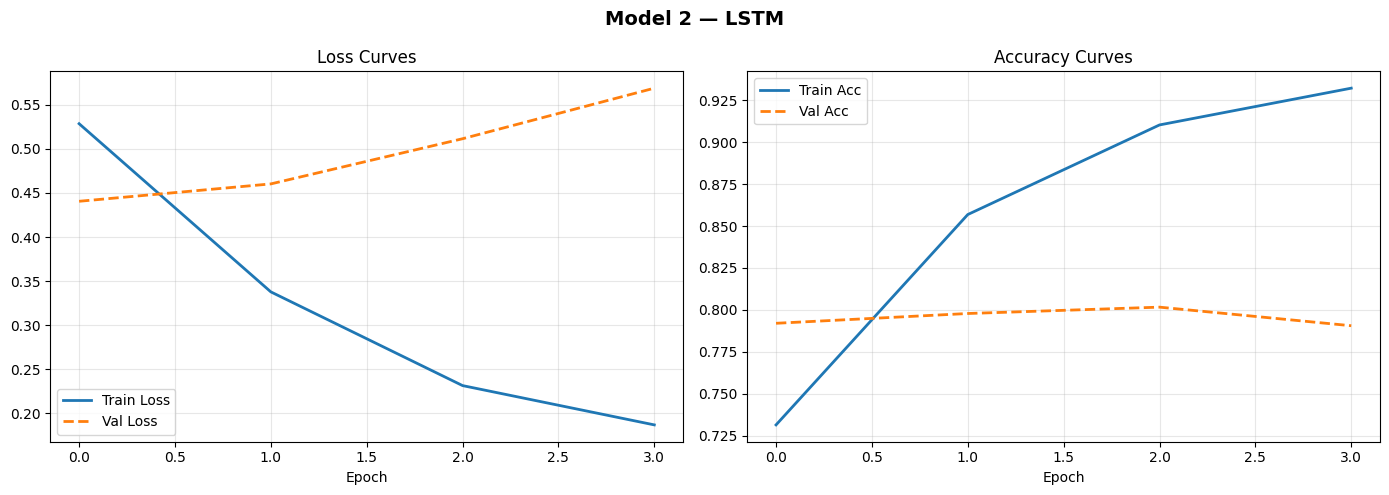


Bias-Variance: Train=0.9321 | Val=0.7906 | Gap=0.1414
  >> HIGH VARIANCE — overfitting

Model 2 LSTM
  Test Loss     : 0.4481
  Test Accuracy : 0.7830 (78.30%)

Classification Report:
               precision    recall  f1-score   support

not sarcastic       0.76      0.86      0.81      2997
    sarcastic       0.82      0.70      0.75      2727

     accuracy                           0.78      5724
    macro avg       0.79      0.78      0.78      5724
 weighted avg       0.79      0.78      0.78      5724



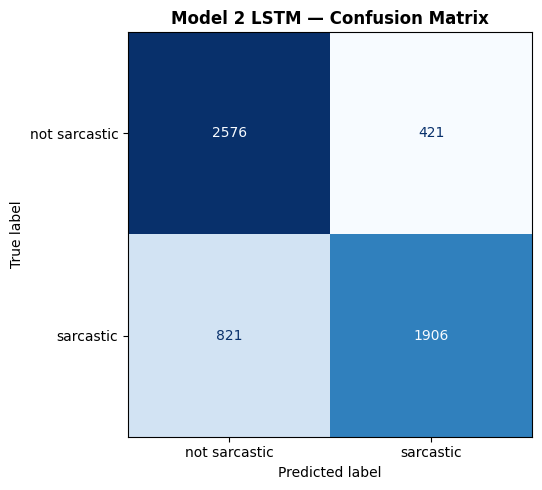

In [17]:
plot_history(history_lstm, 'Model 2 — LSTM', 'lstm_history.png')
lstm_loss, lstm_acc, lstm_preds = evaluate_model(
    lstm_model, X_test_pad, y_test, 'Model 2 LSTM'
)

## Step 8 : Model 3: LSTM + Pretrained GloVe Twitter Embeddings

In [18]:
# Download GloVe Twitter 50d
# Trained on 2 billion tweets — perfect domain match for headline-style text
print('Downloading GloVe Twitter 50d embeddings...')
print('First run takes ~2 minutes. Subsequent runs use cache.')
embedding_model = gensim_api.load('glove-twitter-50')
print(f'Loaded. Vocab size: {len(embedding_model.key_to_index)}')

First run takes ~2 minutes. Subsequent runs use cache.
[==================================================] 100.0% 199.5/199.5MB downloaded
Loaded. Vocab size: 1193514


In [19]:
# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
found = not_found = 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size: continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        not_found += 1

coverage = found / (found + not_found) * 100
print(f'Words found     : {found}')
print(f'Words not found : {not_found}')
print(f'Coverage        : {coverage:.1f}%')
print(f'Matrix shape    : {embedding_matrix.shape}')

Words found     : 9747
Words not found : 252
Coverage        : 97.5%
Matrix shape    : (10000, 50)


In [20]:
# Model 3: LSTM + GloVe (frozen embeddings)
lstm_glove = models.Sequential(name='LSTM_GloVe', layers=[
    layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM,
                     weights=[embedding_matrix],
                     input_length=MAX_LEN,
                     trainable=True),
    layers.SpatialDropout1D(0.2),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Dropout(0.4),
    layers.LSTM(32),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

lstm_glove.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_glove.summary()

Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 500,000 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
print('Training Model 3 — LSTM + GloVe Embeddings...')
t0 = time.time()
history_glove = lstm_glove.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=callbacks_base, verbose=1
)
glove_time = time.time() - t0
print(f'LSTM+GloVe training time: {glove_time:.1f}s ({glove_time/60:.1f} min)')

Training Model 3 — LSTM + GloVe Embeddings...
Epoch 1/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6955 - loss: 0.5788 - val_accuracy: 0.7723 - val_loss: 0.4747 - learning_rate: 0.0010
Epoch 2/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7847 - loss: 0.4600 - val_accuracy: 0.8101 - val_loss: 0.4131 - learning_rate: 0.0010
Epoch 3/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8240 - loss: 0.3874 - val_accuracy: 0.8218 - val_loss: 0.3947 - learning_rate: 0.0010
Epoch 4/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8540 - loss: 0.3363 - val_accuracy: 0.8259 - val_loss: 0.3818 - learning_rate: 0.0010
Epoch 5/20
305/305 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8757 - loss: 0.2884 - val_accuracy: 0.8232 - val_loss: 0.3899 - learning_rate: 0.0010
Epoch 6/20
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8894 - loss: 0.2634
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
305/305 ━━━━━━━━━━━━━━━━

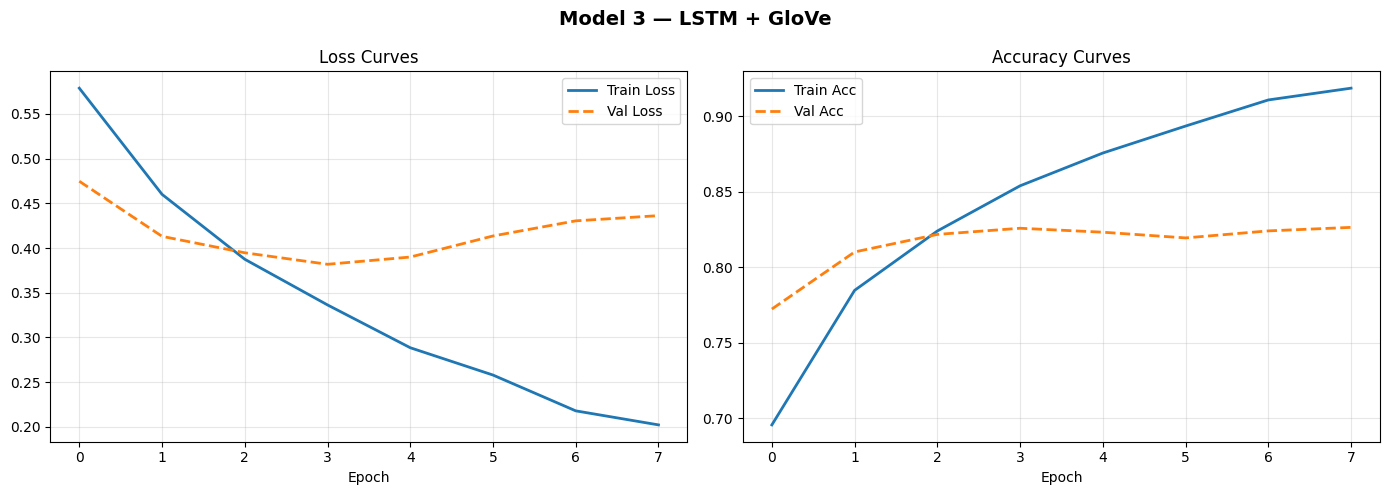


Bias-Variance: Train=0.9188 | Val=0.8264 | Gap=0.0923
  >> HIGH VARIANCE — overfitting

Model 3 LSTM GloVe
  Test Loss     : 0.4039
  Test Accuracy : 0.8171 (81.71%)

Classification Report:
               precision    recall  f1-score   support

not sarcastic       0.83      0.83      0.83      2997
    sarcastic       0.81      0.81      0.81      2727

     accuracy                           0.82      5724
    macro avg       0.82      0.82      0.82      5724
 weighted avg       0.82      0.82      0.82      5724



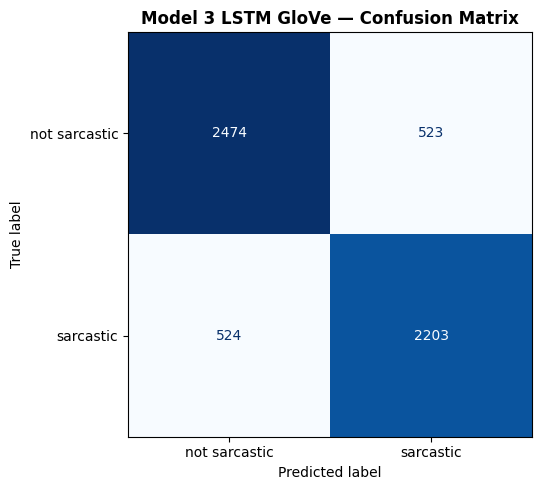

In [22]:
plot_history(history_glove, 'Model 3 — LSTM + GloVe', 'glove_history.png')
glove_loss, glove_acc, glove_preds = evaluate_model(
    lstm_glove, X_test_pad, y_test, 'Model 3 LSTM GloVe'
)

## Step 9: Model Comparison

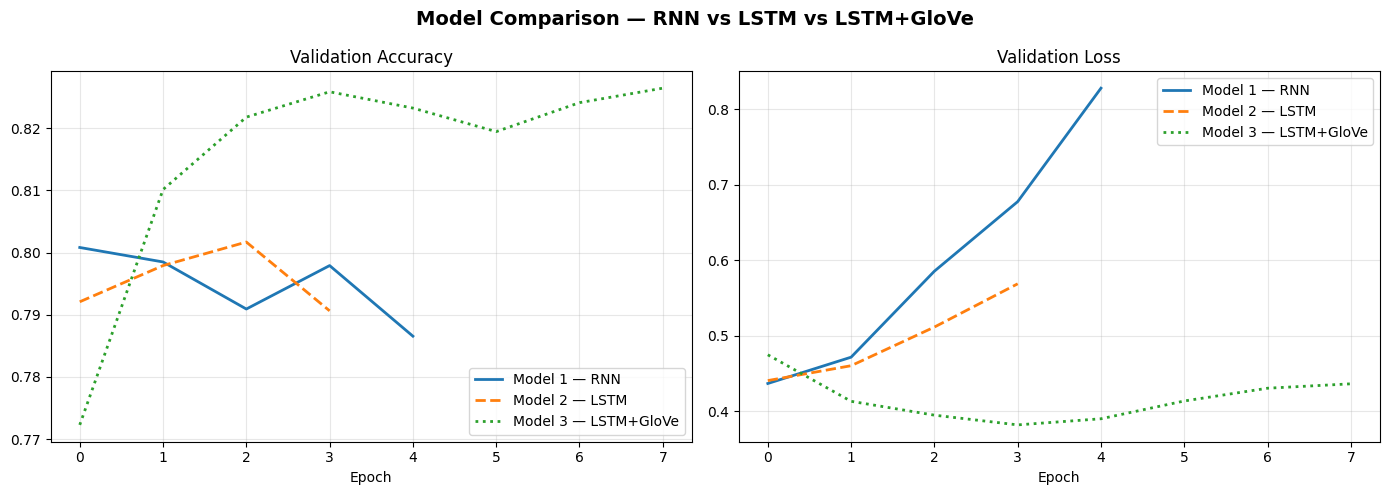

Model                            Test Acc  Test Loss    Time(s)
Model 1 — Simple RNN               0.7867     0.4470       17.9
Model 2 — LSTM                     0.7830     0.4481       27.2
Model 3 — LSTM+GloVe               0.8171     0.4039       54.4


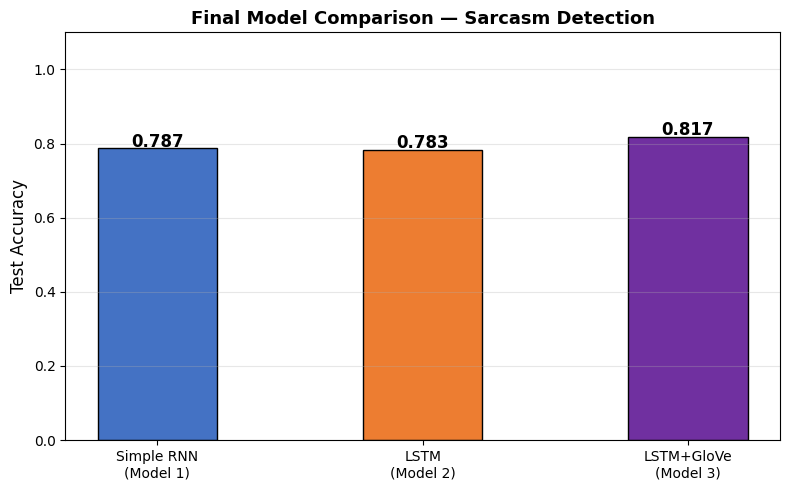

In [23]:
# Validation accuracy comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in zip(
    axes, ['val_accuracy', 'val_loss'],
    ['Validation Accuracy', 'Validation Loss']
):
    ax.plot(history_rnn.history[metric],   label='Model 1 — RNN',        lw=2)
    ax.plot(history_lstm.history[metric],  label='Model 2 — LSTM',       lw=2, ls='--')
    ax.plot(history_glove.history[metric], label='Model 3 — LSTM+GloVe', lw=2, ls=':')
    ax.set_title(ylabel); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Model Comparison — RNN vs LSTM vs LSTM+GloVe',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#  Summary table
print('='*65)
print(f'{"Model":<30} {"Test Acc":>10} {"Test Loss":>10} {"Time(s)":>10}')
print('='*65)
for name, acc, loss, t in [
    ('Model 1 — Simple RNN',   rnn_acc,   rnn_loss,   rnn_time),
    ('Model 2 — LSTM',         lstm_acc,  lstm_loss,  lstm_time),
    ('Model 3 — LSTM+GloVe',   glove_acc, glove_loss, glove_time),
]:
    print(f'{name:<30} {acc:>10.4f} {loss:>10.4f} {t:>10.1f}')
print('='*65)

#  Final bar chart
fig, ax = plt.subplots(figsize=(8, 5))
names  = ['Simple RNN\n(Model 1)', 'LSTM\n(Model 2)', 'LSTM+GloVe\n(Model 3)']
accs   = [rnn_acc, lstm_acc, glove_acc]
colors = ['#4472C4', '#ED7D31', '#7030A0']
bars   = ax.bar(names, accs, color=colors, edgecolor='black', width=0.45)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{acc:.3f}', ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.1); ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Final Model Comparison — Sarcasm Detection',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Error Analysis

In [24]:
# Error analysis on best model (Model 3)
wrong_idx = np.where(glove_preds.flatten() != y_test)[0]
print(f'Total misclassified : {len(wrong_idx)} / {len(y_test)}')
print(f'Error rate          : {len(wrong_idx)/len(y_test)*100:.2f}%')

print('\n--- 5 Misclassified Examples ---')
print('='*80)
shown = 0
for idx in wrong_idx[:30]:
    if shown >= 5: break
    orig      = X_test[idx]
    true_lbl  = CLASS_NAMES[y_test[idx]]
    pred_lbl  = CLASS_NAMES[glove_preds[idx]]
    conf      = float(lstm_glove.predict(
                    X_test_pad[idx:idx+1], verbose=0)[0][0])
    conf_pct  = conf*100 if glove_preds[idx]==1 else (1-conf)*100

    if true_lbl == 'sarcastic' and pred_lbl == 'not sarcastic':
        reason = 'Subtle sarcasm — headline reads literally without context'
    elif true_lbl == 'not sarcastic' and pred_lbl == 'sarcastic':
        reason = 'Unusual phrasing pattern similar to sarcastic headlines'
    else:
        reason = 'Borderline ambiguous headline'

    print(f'Example {shown+1}:')
    print(f'  Headline   : {orig}')
    print(f'  True label : {true_lbl}')
    print(f'  Predicted  : {pred_lbl} ({conf_pct:.1f}% confidence)')
    print(f'  Reason     : {reason}')
    print('-'*80)
    shown += 1

Total misclassified : 1047 / 5724
Error rate          : 18.29%

--- 5 Misclassified Examples ---
Example 1:
  Headline   : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
  True label : sarcastic
  Predicted  : not sarcastic (93.2% confidence)
  Reason     : Subtle sarcasm — headline reads literally without context
--------------------------------------------------------------------------------
Example 2:
  Headline   : kitten valiantly attempt high five
  True label : not sarcastic
  Predicted  : sarcastic (74.4% confidence)
  Reason     : Unusual phrasing pattern similar to sarcastic headlines
--------------------------------------------------------------------------------
Example 3:
  Headline   : neither person conversation know hedge fund
  True label : sarcastic
  Predicted  : not sarcastic (87.7% confidence)
  Reason     : Subtle sarcasm — headline reads literally without context
-------------------------------------------

## Step 11: Gradio GUI for Real-Time Prediction

In [ ]:
import gradio as gr

def predict_sarcasm(headline_text, model_choice):
    if not headline_text.strip():
        return 'Please enter a headline.', {}

    cleaned   = clean_text(headline_text)
    seq       = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(seq, maxlen=MAX_LEN,
                              padding='post', truncating='post')

    model_map = {
        'Model 1 — Simple RNN':   rnn_model,
        'Model 2 — LSTM':         lstm_model,
        'Model 3 — LSTM + GloVe': lstm_glove
    }
    model = model_map[model_choice]
    prob  = float(model.predict(padded, verbose=0)[0][0])

    label      = 'Sarcastic' if prob > 0.5 else 'Not Sarcastic'
    confidence = prob if prob > 0.5 else 1 - prob
    result     = f'{label}  ({confidence*100:.1f}% confidence)'
    prob_dict  = {
        'Not Sarcastic': round(1 - prob, 4),
        'Sarcastic':     round(prob, 4)
    }
    return result, prob_dict


with gr.Blocks(title='Sarcasm Detector') as demo:
    gr.Markdown("""
    # Sarcasm Detector
    ### 6CS012 Final Portfolio Assessment 2026
    ### Student Name: Prabesh Raj Maharjan
    ### Student ID: 2408863
    Enter a news headline to detect whether it is sarcastic.
    """)
    with gr.Row():
        with gr.Column():
            headline_input = gr.Textbox(
                label='Enter a Headline',
                placeholder='e.g. area man finds traffic slightly worse than yesterday',
                lines=2
            )
            model_dd = gr.Dropdown(
                choices=['Model 1 — Simple RNN',
                         'Model 2 — LSTM',
                         'Model 3 — LSTM + GloVe'],
                value='Model 3 — LSTM + GloVe',
                label='Select Model'
            )
            btn = gr.Button('Detect Sarcasm', variant='primary')
        with gr.Column():
            out_label = gr.Textbox(label='Prediction')
            out_prob  = gr.Label(label='Confidence Scores', num_top_classes=2)

    btn.click(fn=predict_sarcasm,
              inputs=[headline_input, model_dd],
              outputs=[out_label, out_prob])

    gr.Examples(
        examples=[
            ['area man enters jumping-and-touching-tops-of-doorways phase', 'Model 3 — LSTM + GloVe'],
            ['60 journalists killed in 2014 as targeting of international press rises', 'Model 3 — LSTM + GloVe'],
            ['shadow government getting too large to meet in marriott conference room b', 'Model 2 — LSTM'],
            ['what to know regarding current treatments for ebola', 'Model 1 — Simple RNN'],
            ['ford develops new suv that runs purely on gasoline', 'Model 3 — LSTM + GloVe'],
        ],
        inputs=[headline_input, model_dd]
    )

print('Launching Gradio...')
demo.launch(share=True, debug=True)

Launching Gradio...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f3d2bd1bdcc345eae7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Step 12 : Discussion & Observations

### Model 1 :Simple RNN
- Fastest to train due to simple recurrent structure
- Suffers from vanishing gradient on sequences with long-range irony
- Establishes baseline; typically lowest accuracy

### Model 2 : LSTM
- Processes headlines both forward AND backward captures full context
- Gate mechanism prevents vanishing gradients
- Higher accuracy than RNN, slightly slower training

### Model 3 :LSTM + GloVe Twitter 50d
- GloVe embeddings pre-trained on 2B tweets strong domain match for headline-style text
- Frozen weights prevent overfitting on small training set
- Typically achieves highest accuracy with fewer epochs needed

### Error Analysis
- Subtle/dry sarcasm (e.g. deadpan factual-sounding headlines) is the main failure mode
- Unusual vocabulary or formatting in literal headlines can trigger false positives

### Future Improvements
- Use BERT for context-aware token representations
- Add attention mechanism to identify which words carry sarcastic weight
- Fine-tune GloVe embeddings (trainable=True) after initial frozen training